In [1]:
### Initializing Gee

In [2]:
import geemap
import ee

import random
from shapely.geometry import Polygon, mapping
import geopandas as gpd

m = geemap.Map()
m

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
#### NDVI Analaysis Per Watershed Site, Works properly....

In [3]:
#### Clean script for removing the points around violin for some plot and leaving for the other..

In [34]:
# ============================================
# MARKOM SOLAR SITE — NDVI (2022, 2023, 2024)
# Window: Sep 01 -> Oct 01 (same for each year)
#
# Outputs (per year):
#   - markom_site_ndvi_200grid_YYYY_0901_1001.csv
#   - markom_ndvi_summary_stats_YYYY_0901_1001.csv
#
# Output (all years combined; CSV only, NO PLOTS):
#   - markom_site_ndvi_200grid_ALL_2022_2023_2024_0901_1001.csv
#   - markom_ndvi_summary_stats_ALL_2022_2023_2024_0901_1001.csv
#
# Figures (ONLY these):
#   - Plotly dark HTML: 1x3 (2022 | 2023 | 2024)
#   - Matplotlib/Seaborn PNG: 1x3 (2022 | 2023 | 2024) higher contrast
#
# CRS: EPSG:26914
# Grid: ~200 cells per shapefile
# ============================================

import os, time
from datetime import datetime
from pathlib import Path

import geopandas as gpd
from shapely.errors import TopologicalError
import pandas as pd

import ee, geemap

# ----------------------------------
# CONFIG
# ----------------------------------
SHAPE_DIR = r"elevation_analysis/talbert/watersheds_talbert"

OUTDIR   = Path(r"lulc_analysis_report/veg_report/talbert_veg_report/violin_ndvi/new_plot")
PLOT_OUT = OUTDIR / "publication_figs"
OUTDIR.mkdir(parents=True, exist_ok=True)
PLOT_OUT.mkdir(parents=True, exist_ok=True)

WORK_EPSG = 26914
TARGET_CELLS = 800
CLOUDY_PCT_MAX = 10
NDVI_SCALE = 10
TILE_SCALE = 4

# >>> CHANGED: 3 years
YEARS = [2022, 2023, 2024]
WIN_START = "-09-01"
WIN_END   = "-10-01"
WIN_TAG   = "0901_1001"

GROUP_NAME = "Markom Solar Site"

SITE_MAP = {
    "china_spring_ranch": ("ChinaSpringRef", "China Spring Ref"),
    "manamay_ranch":      ("McMRanchRef",   "McM Ranch Ref"),
    "talbert_ranch":      ("TalbertImpact", "Talbert Ranch Impact"),
    "talbert_360":        ("TalbertDS",     "Talbert 360 Downstream"),
}
SITE_ORDER_CODES   = ["ChinaSpringRef", "McMRanchRef", "TalbertImpact", "TalbertDS"]
SITE_ORDER_LABELS  = [SITE_MAP[k][1] for k in ["china_spring_ranch","manamay_ranch","talbert_ranch","talbert_360"]]
SITE_LABELS_WRAPPED = {
    "China Spring Ref":       "China Spring<br>Ref",
    "McM Ranch Ref":          "McM Ranch<br>Ref",
    "Talbert Ranch Impact":   "Talbert Ranch<br>Impact",
    "Talbert 360 Downstream": "Talbert 360<br>Downstream",
}

# ----------------------------------
# UTILS
# ----------------------------------
def now(): return datetime.now().strftime("%H:%M:%S")
def secstr(s): return f"{s:.1f}s"
def stage(msg): print(f"\n[{now()}] {msg}")

def ensure_dir(p: Path):
    target = p if p.suffix == "" else p.parent
    target.mkdir(parents=True, exist_ok=True)

def safe_to_csv(df: pd.DataFrame, path: Path, tries: int = 3, delay: float = 1.0):
    path = Path(path)
    for k in range(tries):
        try:
            ensure_dir(path)
            tmp = path.with_suffix(path.suffix + ".tmp")
            df.to_csv(tmp, index=False)
            tmp.replace(path)
            return
        except OSError as e:
            print(f"  Write attempt {k+1}/{tries} failed for {path}: {e}")
            time.sleep(delay)
    raise

# ----------------------------------
# STEP 1 — Load 4 shapefiles
# ----------------------------------
t0 = time.perf_counter()
stage("Step 1/5 — Scanning shapefiles...")

shape_paths = sorted([str(Path(SHAPE_DIR)/f)
                      for f in os.listdir(SHAPE_DIR)
                      if f.lower().endswith(".shp")])

expected = set(SITE_MAP.keys())
shape_paths = [p for p in shape_paths if Path(p).stem in expected]
if len(shape_paths) != 4:
    raise FileNotFoundError(
        f"Expected 4 shapefiles {sorted(expected)} in {SHAPE_DIR}, found {len(shape_paths)}."
    )

print(f"Found {len(shape_paths)} shapefiles.")
gdfs = []

for idx, shp in enumerate(shape_paths, start=1):
    t_i = time.perf_counter()
    base = Path(shp).stem
    print(f"  [{idx}/4] Loading {base} ...", end="", flush=True)
    gdf0 = gpd.read_file(shp)
    if gdf0.crs is None:
        raise ValueError(f"{base} has no CRS.")
    gdf = gdf0.to_crs(epsg=WORK_EPSG)

    try:
        gdf["geometry"] = gdf["geometry"].buffer(0)
    except TopologicalError:
        gdf = gdf[gdf.is_valid].copy()

    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notnull()].copy()

    if "sub_id" not in gdf.columns:
        gdf["sub_id"] = base

    code, label = SITE_MAP[base]
    gdf["group"] = GROUP_NAME
    gdf["site_code"] = code
    gdf["site_label"] = label

    gdfs.append(gdf[["group","sub_id","site_code","site_label","geometry"]])
    print(f" done ({secstr(time.perf_counter()-t_i)})")

subws_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=f"EPSG:{WORK_EPSG}")
print(subws_gdf[["sub_id","group","site_code","site_label"]])
print(f"Total sub-watersheds: {len(subws_gdf)}")
print(f"Step 1/5 completed in {secstr(time.perf_counter()-t0)}")

# ----------------------------------
# STEP 2 — EE init + to FeatureCollection
# ----------------------------------
t1 = time.perf_counter()
stage("Step 2/5 — Initializing Earth Engine...")
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

subws_fc = geemap.gdf_to_ee(subws_gdf, geodesic=False)
print("EE FeatureCollection created.")
print(f"Step 2/5 completed in {secstr(time.perf_counter()-t1)}")

# ----------------------------------
# STEP 3 — Build ~200-cell grid per polygon
# ----------------------------------
t2 = time.perf_counter()
stage("Step 3/5 — Building ~200-cell grids per sub-watershed...")

PROJ = ee.Projection(f"EPSG:{WORK_EPSG}")

def build_grid_for(feature):
    f = ee.Feature(feature)
    geom = f.geometry()
    geom_proj = geom.transform(PROJ, 1)
    bounds = geom_proj.bounds(1, PROJ)
    coords = ee.List(ee.List(bounds.coordinates()).get(0))
    xmin = ee.Number(ee.List(coords.get(0)).get(0))
    ymin = ee.Number(ee.List(coords.get(0)).get(1))
    xmax = ee.Number(ee.List(coords.get(2)).get(0))
    ymax = ee.Number(ee.List(coords.get(2)).get(1))

    width_m  = xmax.subtract(xmin)
    height_m = ymax.subtract(ymin)
    aspect   = width_m.divide(height_m)

    nx0 = ee.Number(TARGET_CELLS).multiply(aspect).sqrt().ceil()
    ny0 = ee.Number(TARGET_CELLS).divide(nx0).ceil()

    def _build(nx, ny):
        dx, dy = width_m.divide(nx), height_m.divide(ny)
        xi, yj = ee.List.sequence(0, nx.subtract(1)), ee.List.sequence(0, ny.subtract(1))
        def _row(j):
            j = ee.Number(j)
            y0 = ymin.add(dy.multiply(j)); y1 = y0.add(dy)
            def _cell(i):
                i = ee.Number(i)
                x0 = xmin.add(dx.multiply(i)); x1 = x0.add(dx)
                return ee.Feature(ee.Geometry.Rectangle([x0, y0, x1, y1], PROJ, False))
            return ee.FeatureCollection(xi.map(_cell))
        return ee.FeatureCollection(yj.map(_row)).flatten()

    def _clip(grid_fc):
        return (grid_fc.filterBounds(geom)
                       .map(lambda g: ee.Feature(g).intersection(geom, 1))
                       .map(lambda ft: ee.Feature(ft).set("area_m2", ee.Feature(ft).geometry().area(1)))
                       .filter(ee.Filter.gt("area_m2", 1.0)))

    grid = _clip(_build(nx0, ny0))
    sizes = [grid.size(),
             _clip(_build(nx0.add(2), ny0.add(2))).size(),
             _clip(_build(nx0.add(4), ny0.add(4))).size()]
    # chosen = ee.Algorithms.If(sizes[0].gte(180), grid,
    #           ee.Algorithms.If(sizes[1].gte(180), _clip(_build(nx0.add(2), ny0.add(2))),
    #                            _clip(_build(nx0.add(4), ny0.add(4)))))

    threshold = ee.Number(TARGET_CELLS).multiply(0.9)  # ~90% of target
    chosen = ee.Algorithms.If(sizes[0].gte(threshold), grid,
              ee.Algorithms.If(sizes[1].gte(threshold), _clip(_build(nx0.add(2), ny0.add(2))),
                               _clip(_build(nx0.add(4), ny0.add(4)))))
    chosen = ee.FeatureCollection(chosen)

    group, subid = f.get("group"), f.get("sub_id")
    site_code, site_label = f.get("site_code"), f.get("site_label")
    lst = chosen.toList(chosen.size())
    indexed = ee.List.sequence(0, lst.size().subtract(1)).map(
        lambda i: ee.Feature(lst.get(i)).set({
            "group": group,
            "sub_id": subid,
            "site_code": site_code,
            "site_label": site_label,
            "grid_id": i
        })
    )
    return ee.FeatureCollection(indexed)

grids_fc = subws_fc.map(build_grid_for).flatten()
n_cells = grids_fc.size().getInfo()
print(f"Built grids (~200/subwatershed target). Total grid features: {n_cells}")
print(f"Step 3/5 completed in {secstr(time.perf_counter()-t2)}")

# ----------------------------------
# STEP 4 — Fetch & clean NDVI per year
# ----------------------------------
def s2_sr(aoi, start, end):
    col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(aoi)
           .filterDate(start, end)
           .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", CLOUDY_PCT_MAX)))
    def mask_scl(img):
        scl = img.select("SCL")
        mask = (scl.neq(3).And(scl.neq(8)).And(scl.neq(9))
                .And(scl.neq(10)).And(scl.neq(11)))
        return img.updateMask(mask)
    return col.map(mask_scl)

def compute_year_df(year: int) -> pd.DataFrame:
    start = f"{year}{WIN_START}"
    end   = f"{year}{WIN_END}"

    stage(f"NDVI — Reducing for {year} ({start} to {end})...")
    s2 = s2_sr(grids_fc.geometry(), start, end).map(
        lambda img: img.addBands(img.normalizedDifference(["B8","B4"]).rename("NDVI"))
    )
    img_count = s2.size().getInfo()
    print(f"  Sentinel-2 images in window: {img_count}")
    if img_count == 0:
        raise RuntimeError(f"No S2 images for {year} in {start} to {end}")

    ndvi_med = s2.select("NDVI").median()
    stats_fc = ndvi_med.reduceRegions(
        collection=grids_fc,
        reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True),
        scale=NDVI_SCALE, tileScale=TILE_SCALE
    )

    try:
        df = geemap.ee_to_geopandas(stats_fc)
        df = df.drop(columns="geometry", errors="ignore")
        print(f"  Records via ee_to_geopandas: {len(df):,}")
    except Exception:
        feats = stats_fc.getInfo().get("features", [])
        if not feats:
            raise RuntimeError(f"NDVI export empty for {year}")
        df = pd.DataFrame([f["properties"] for f in feats])
        print(f"  Records via getInfo(): {len(df):,}")

    df = df.rename(columns={"mean":"ndvi_mean","stdDev":"ndvi_std"}).dropna(subset=["ndvi_mean"]).copy()
    df = df[(df["ndvi_mean"] >= -0.1) & (df["ndvi_mean"] <= 1.0)].copy()

    df["group"] = GROUP_NAME
    df["site_code"]  = pd.Categorical(df["site_code"], categories=SITE_ORDER_CODES, ordered=True)
    df["site_label"] = pd.Categorical(df["site_label"], categories=SITE_ORDER_LABELS, ordered=True)
    df = df.sort_values(["site_code","sub_id","grid_id"]).reset_index(drop=True)

    markom_csv = OUTDIR / f"markom_site_ndvi_200grid_{year}_{WIN_TAG}.csv"
    safe_to_csv(df[["group","sub_id","site_code","site_label","grid_id","ndvi_mean","ndvi_std"]], markom_csv)
    print(f"  CSV saved → {markom_csv}")

    summary_stats = (
        df.groupby(["site_code","site_label"])
          .agg(n=("ndvi_mean","size"),
               mean_ndvi=("ndvi_mean","mean"),
               sd_ndvi=("ndvi_mean","std"),
               min_ndvi=("ndvi_mean","min"),
               q25=("ndvi_mean", lambda x: x.quantile(0.25)),
               median_ndvi=("ndvi_mean","median"),
               q75=("ndvi_mean", lambda x: x.quantile(0.75)),
               max_ndvi=("ndvi_mean","max"))
          .reset_index()
          .sort_values(["site_code"])
    )
    summary_csv = OUTDIR / f"markom_ndvi_summary_stats_{year}_{WIN_TAG}.csv"
    safe_to_csv(summary_stats, summary_csv)
    print(f"  Summary stats saved → {summary_csv}")

    return df

t3 = time.perf_counter()
stage("Step 4/5 — Fetching NDVI for 2022, 2023, and 2024...")
df_by_year = {yr: compute_year_df(yr) for yr in YEARS}
print(f"Step 4/5 completed in {secstr(time.perf_counter()-t3)}")

# ---- Create ALL-YEARS CSV ONLY (no plots) ----
stage("Step 4b/5 — Writing ALL-YEARS combined CSV (no plots)...")
df_all_years = pd.concat([df_by_year[y] for y in YEARS], ignore_index=True)

all_csv = OUTDIR / f"markom_site_ndvi_200grid_ALL_2022_2023_2024_{WIN_TAG}.csv"
safe_to_csv(df_all_years[["group","sub_id","site_code","site_label","grid_id","ndvi_mean","ndvi_std"]], all_csv)
print(f"  ALL-years CSV saved → {all_csv}")

all_summary = (
    df_all_years.groupby(["site_code","site_label"])
    .agg(n=("ndvi_mean","size"),
         mean_ndvi=("ndvi_mean","mean"),
         sd_ndvi=("ndvi_mean","std"),
         min_ndvi=("ndvi_mean","min"),
         q25=("ndvi_mean", lambda x: x.quantile(0.25)),
         median_ndvi=("ndvi_mean","median"),
         q75=("ndvi_mean", lambda x: x.quantile(0.75)),
         max_ndvi=("ndvi_mean","max"))
    .reset_index()
    .sort_values(["site_code"])
)
all_summary_csv = OUTDIR / f"markom_ndvi_summary_stats_ALL_2022_2023_2024_{WIN_TAG}.csv"
safe_to_csv(all_summary, all_summary_csv)
print(f"  ALL-years summary CSV saved → {all_summary_csv}")

# ----------------------------------
# STEP 5 — ONLY 2022, 2023, and 2024 plots
# ----------------------------------
stage("Step 5/5 — Building 2022, 2023 & 2024 figures ONLY...")

def _prep_for_plot(d):
    d = d.copy()
    d["site_label"] = pd.Categorical(d["site_label"], categories=SITE_ORDER_LABELS, ordered=True)
    d["site_label_wrapped"] = d["site_label"].astype(str).map(SITE_LABELS_WRAPPED)
    return d

# ---------- Plotly (dark) 1x3 ----------
from plotly.subplots import make_subplots
import plotly.graph_objects as go

site_color_map = {
    "China Spring Ref":       "#A1C5FF",
    "McM Ranch Ref":          "#E3D26F",
    "Talbert Ranch Impact":   "#F29E4C",
    "Talbert 360 Downstream": "#E85D75",
}

fig = make_subplots(
    rows=1, cols=3,
    horizontal_spacing=0.06,
    subplot_titles=[f"{GROUP_NAME} — 2022", f"{GROUP_NAME} — 2023", f"{GROUP_NAME} — 2024"]
)

for year, col in [(2022, 1), (2023, 2), (2024, 3)]:
    d = _prep_for_plot(df_by_year[year])
    for lbl in SITE_ORDER_LABELS:
        sdata = d[d["site_label"] == lbl]
        if sdata.empty:
            continue
        fig.add_trace(
            go.Violin(
                y=sdata["ndvi_mean"],
                x=[SITE_LABELS_WRAPPED[lbl]] * len(sdata),
                name=lbl,
                showlegend=(year == 2024),   # legend only once
                box_visible=True, meanline_visible=True, points="all",
                marker=dict(opacity=0.6),
                line=dict(width=1.2, color="white"),
                fillcolor=site_color_map.get(lbl, "#BBBBBB"),
                opacity=0.95
            ),
            row=1, col=col
        )

for c in [1, 2, 3]:
    fig.update_xaxes(
        tickangle=-25,
        automargin=True,
        categoryorder="array",
        categoryarray=[SITE_LABELS_WRAPPED[k] for k in SITE_ORDER_LABELS],
        row=1, col=c
    )
    fig.update_yaxes(range=[0, 1], showgrid=True, gridcolor="#606060",
                     gridwidth=0.6, zeroline=False, row=1, col=c)

fig.update_layout(
    template="plotly_dark",
    title=dict(text=f"Markom NDVI Distribution by Site (Sep 1–Oct 1) — 2022–2024",
               x=0.5, font=dict(size=22, color="white")),
    height=560, width=2100,
    paper_bgcolor="#2a2a2a", plot_bgcolor="#2a2a2a",
    font=dict(family="Arial", size=13, color="white"),
    margin=dict(l=110, r=40, t=85, b=80)
)

plotly_out = OUTDIR / f"markom_violin_ndvi_1x3_DARK_{WIN_TAG}_2022_2023_2024.html"
ensure_dir(plotly_out)
fig.write_html(plotly_out)
print(f"Plotly 1x3 saved → {plotly_out}")

# ----------------------------------
# STEP 5 — 2022, 2023, 2024 STOTEN PNGs (FOUR VERSIONS)
#   A) 3 rows, violin only
#   B) 3 rows, violin + points
#   C) 3 cols, violin only
#   D) 3 cols, violin + points
# ----------------------------------
stage("Step 5/5 — Building STOTEN PNGs (4 versions: rows/cols × points on/off)...")

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from pathlib import Path

YEARS_PLOT = YEARS  # expects [2022, 2023, 2024]

# ---------- Matplotlib/Seaborn style (same as your prior) ----------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "axes.linewidth": 0.9,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 700,
    "figure.dpi": 160,
})

def _prep_for_plot(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["site_label"] = pd.Categorical(d["site_label"], categories=SITE_ORDER_LABELS, ordered=True)
    return d

def draw_panel(ax, d, title, ylabel="", show_points=True):
    """
    show_points=False => violin only
    show_points=True  => violin + strip points around violin
    """
    d = _prep_for_plot(d)
    order = SITE_ORDER_LABELS

    # Violin: light gray
    sns.violinplot(
        data=d, x="site_label", y="ndvi_mean",
        order=order, inner="box", cut=0,
        linewidth=0.9, color="#D9D9D9", saturation=1.0, ax=ax
    )

    # Points: only if requested
    if show_points:
        sns.stripplot(
            data=d, x="site_label", y="ndvi_mean",
            order=order, color="black",
            size=2.2, alpha=0.80, jitter=0.22, ax=ax
        )

    ax.set_title(title, pad=6)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)

    for tick in ax.get_xticklabels():
        tick.set_rotation(25)
        tick.set_horizontalalignment("right")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# Ensure PLOT_OUT exists
PLOT_OUT = Path(PLOT_OUT)
PLOT_OUT.mkdir(parents=True, exist_ok=True)

years_tag = "_".join([str(y) for y in YEARS_PLOT])  # "2022_2023_2024"

# ==========================
# A) 3x1 (three rows) — violin ONLY
# ==========================
fig_r0, axes_r0 = plt.subplots(len(YEARS_PLOT), 1, figsize=(6.8, 10.8), sharey=True)
if len(YEARS_PLOT) == 1:
    axes_r0 = [axes_r0]

for i, yr in enumerate(YEARS_PLOT):
    draw_panel(
        axes_r0[i],
        df_by_year[yr],
        f"{GROUP_NAME} — {yr}",
        ylabel="NDVI" if i == 0 else "",
        show_points=False
    )

fig_r0.tight_layout(pad=0.9, h_pad=1.4)
fig_r0.subplots_adjust(bottom=0.10)

out_r0 = PLOT_OUT / f"markom_violin_ndvi_3x1_NOPOINTS_{WIN_TAG}_{years_tag}.png"
fig_r0.savefig(out_r0, bbox_inches="tight")
plt.close(fig_r0)
print(f"STOTEN PNG (3 rows, violin only) saved → {out_r0}")

# ==========================
# B) 3x1 (three rows) — violin + points
# ==========================
fig_r1, axes_r1 = plt.subplots(len(YEARS_PLOT), 1, figsize=(6.8, 10.8), sharey=True)
if len(YEARS_PLOT) == 1:
    axes_r1 = [axes_r1]

for i, yr in enumerate(YEARS_PLOT):
    draw_panel(
        axes_r1[i],
        df_by_year[yr],
        f"{GROUP_NAME} — {yr}",
        ylabel="NDVI" if i == 0 else "",
        show_points=True
    )

fig_r1.tight_layout(pad=0.9, h_pad=1.4)
fig_r1.subplots_adjust(bottom=0.10)

out_r1 = PLOT_OUT / f"markom_violin_ndvi_3x1_POINTS_{WIN_TAG}_{years_tag}.png"
fig_r1.savefig(out_r1, bbox_inches="tight")
plt.close(fig_r1)
print(f"STOTEN PNG (3 rows, violin + points) saved → {out_r1}")

# ==========================
# C) 1x3 (three columns) — violin ONLY
# ==========================
fig_c0, axes_c0 = plt.subplots(1, len(YEARS_PLOT), figsize=(16.0, 4.4), sharey=True)
if len(YEARS_PLOT) == 1:
    axes_c0 = [axes_c0]

for i, yr in enumerate(YEARS_PLOT):
    draw_panel(
        axes_c0[i],
        df_by_year[yr],
        f"{GROUP_NAME} — {yr}",
        ylabel="NDVI" if i == 0 else "",
        show_points=False
    )

fig_c0.tight_layout(pad=0.9, w_pad=1.6)
fig_c0.subplots_adjust(bottom=0.22)

out_c0 = PLOT_OUT / f"markom_violin_ndvi_1x3_NOPOINTS_{WIN_TAG}_{years_tag}.png"
fig_c0.savefig(out_c0, bbox_inches="tight")
plt.close(fig_c0)
print(f"STOTEN PNG (3 cols, violin only) saved → {out_c0}")

# ==========================
# D) 1x3 (three columns) — violin + points
# ==========================
fig_c1, axes_c1 = plt.subplots(1, len(YEARS_PLOT), figsize=(16.0, 4.4), sharey=True)
if len(YEARS_PLOT) == 1:
    axes_c1 = [axes_c1]

for i, yr in enumerate(YEARS_PLOT):
    draw_panel(
        axes_c1[i],
        df_by_year[yr],
        f"{GROUP_NAME} — {yr}",
        ylabel="NDVI" if i == 0 else "",
        show_points=True
    )

fig_c1.tight_layout(pad=0.9, w_pad=1.6)
fig_c1.subplots_adjust(bottom=0.22)

out_c1 = PLOT_OUT / f"markom_violin_ndvi_1x3_POINTS_{WIN_TAG}_{years_tag}.png"
fig_c1.savefig(out_c1, bbox_inches="tight")
plt.close(fig_c1)
print(f"STOTEN PNG (3 cols, violin + points) saved → {out_c1}")

print("\nAll 4 STOTEN PNG outputs written to:", PLOT_OUT)

print("\nAll outputs written to:", OUTDIR)


[20:53:26] Step 1/5 — Scanning shapefiles...
Found 4 shapefiles.
  [1/4] Loading china_spring_ranch ... done (0.1s)
  [2/4] Loading manamay_ranch ... done (0.0s)
  [3/4] Loading talbert_360 ... done (0.0s)
  [4/4] Loading talbert_ranch ... done (0.0s)
               sub_id              group       site_code  \
0  china_spring_ranch  Markom Solar Site  ChinaSpringRef   
1       manamay_ranch  Markom Solar Site     McMRanchRef   
2         talbert_360  Markom Solar Site       TalbertDS   
3       talbert_ranch  Markom Solar Site   TalbertImpact   

               site_label  
0        China Spring Ref  
1           McM Ranch Ref  
2  Talbert 360 Downstream  
3    Talbert Ranch Impact  
Total sub-watersheds: 4
Step 1/5 completed in 0.2s

[20:53:26] Step 2/5 — Initializing Earth Engine...
EE FeatureCollection created.
Step 2/5 completed in 0.3s

[20:53:26] Step 3/5 — Building ~200-cell grids per sub-watershed...
Built grids (~200/subwatershed target). Total grid features: 2555
Step 3/5 co

C:\Users\Emeka_Orji1\AppData\Local\Temp\ipykernel_15252\2539229456.py:299: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



  Sentinel-2 images in window: 7
  Records via getInfo(): 2,555
  CSV saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\markom_site_ndvi_200grid_2023_0901_1001.csv
  Summary stats saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\markom_ndvi_summary_stats_2023_0901_1001.csv

[20:54:43] NDVI — Reducing for 2024 (2024-09-01 to 2024-10-01)...


C:\Users\Emeka_Orji1\AppData\Local\Temp\ipykernel_15252\2539229456.py:299: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



  Sentinel-2 images in window: 7
  Records via getInfo(): 2,555
  CSV saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\markom_site_ndvi_200grid_2024_0901_1001.csv
  Summary stats saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\markom_ndvi_summary_stats_2024_0901_1001.csv
Step 4/5 completed in 106.7s

[20:55:24] Step 4b/5 — Writing ALL-YEARS combined CSV (no plots)...
  ALL-years CSV saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\markom_site_ndvi_200grid_ALL_2022_2023_2024_0901_1001.csv
  ALL-years summary CSV saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\markom_ndvi_summary_stats_ALL_2022_2023_2024_0901_1001.csv

[20:55:24] Step 5/5 — Building 2022, 2023 & 2024 figures ONLY...


C:\Users\Emeka_Orji1\AppData\Local\Temp\ipykernel_15252\2539229456.py:299: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Emeka_Orji1\AppData\Local\Temp\ipykernel_15252\2539229456.py:331: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Plotly 1x3 saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\markom_violin_ndvi_1x3_DARK_0901_1001_2022_2023_2024.html

[20:55:25] Step 5/5 — Building STOTEN PNGs (4 versions: rows/cols × points on/off)...
STOTEN PNG (3 rows, violin only) saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\publication_figs\markom_violin_ndvi_3x1_NOPOINTS_0901_1001_2022_2023_2024.png
STOTEN PNG (3 rows, violin + points) saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\publication_figs\markom_violin_ndvi_3x1_POINTS_0901_1001_2022_2023_2024.png
STOTEN PNG (3 cols, violin only) saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\publication_figs\markom_violin_ndvi_1x3_NOPOINTS_0901_1001_2022_2023_2024.png
STOTEN PNG (3 cols, violin + points) saved → lulc_analysis_report\veg_report\talbert_veg_report\violin_ndvi\new_plot\publication_figs\markom_violin_ndvi_1x3_POINTS_0901_1001_2022_2023_2024.

In [29]:
### Best script to export grided shapefile with NDVI values for any one watershed or date of my choosing for mapping any number of years

In [28]:
# ============================================
# MARKOM SOLAR SITE — Export GRID + NDVI shapefile for ONE chosen watershed shapefile
# Years: 2022, 2023, 2024, 2025
# Window: Apr 01 -> May 01  (April-only composite)
#
# Outputs (one per year):
#   markom_<sub_id>_ndvi_grid<TARGET_CELLS>_<YEAR>_0401_0501.shp
#
# CRS: EPSG:26914
# ============================================

import os
from datetime import datetime
from pathlib import Path

import geopandas as gpd
import ee
import geemap

# ----------------------------------
# CONFIG — EDIT THESE
# ----------------------------------
SHAPE_DIR = r"elevation_analysis/talbert/watersheds_talbert"

OUTDIR = Path(r"lulc_analysis_report/veg_report/talbert_veg_report/ndvi_grid_exports_local/single_watershed_april_2022_2025")
OUTDIR.mkdir(parents=True, exist_ok=True)

WORK_EPSG = 26914

# >>> Choose which watershed to export (must match a .shp stem in SHAPE_DIR)
# Options:
#   "china_spring_ranch", "manamay_ranch", "talbert_ranch", "talbert_360"
TARGET_WATERSHED = "talbert_ranch"

# Grid settings (≈TARGET_CELLS)
TARGET_CELLS = 800
MIN_CELL_AREA_M2 = 1.0

# NDVI settings
CLOUDY_PCT_MAX = 10
NDVI_SCALE = 10
TILE_SCALE = 4

# Years + window (APRIL ONLY)
YEARS = [2022, 2023, 2024]
WIN_START = "-09-01"
WIN_END   = "-10-01"
WIN_TAG   = "0901_1001"

# (Optional) short metadata fields to store in shapefile (DBF-safe)
SITE_CODE  = "MARKOM"   # <=10 chars
SITE_LABEL = "MARKOM"   # <=10 chars

# ----------------------------------
# UTILS
# ----------------------------------
def now():
    return datetime.now().strftime("%H:%M:%S")

def stage(msg):
    print(f"\n[{now()}] {msg}")

def fix_geometries_gdf(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.loc[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()
    if gdf.empty:
        return gdf

    # Prefer GeoSeries.make_valid (GeoPandas >= ~0.13)
    try:
        mv = getattr(gdf.geometry, "make_valid", None)
        if callable(mv):
            gdf["geometry"] = mv()
    except Exception:
        pass

    # Fallback: shapely make_valid (if available)
    try:
        from shapely.validation import make_valid as shapely_make_valid
        gdf["geometry"] = gdf.geometry.apply(shapely_make_valid)
    except Exception:
        pass

    # buffer(0) only polygons
    try:
        poly_mask = gdf.geom_type.isin(["Polygon", "MultiPolygon"])
        if poly_mask.any():
            gdf.loc[poly_mask, "geometry"] = gdf.loc[poly_mask, "geometry"].buffer(0)
    except Exception:
        pass

    gdf = gdf.loc[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()
    return gdf

# ----------------------------------
# EE GRID BUILDER (~TARGET_CELLS)
# ----------------------------------
PROJ = ee.Projection(f"EPSG:{WORK_EPSG}")

def build_grid_for_geom(geom, sub_id: str, site_cd: str, site_lbl: str):
    geom = ee.Geometry(geom).transform(PROJ, 1)
    bounds = geom.bounds(1, PROJ)

    coords = ee.List(ee.List(bounds.coordinates()).get(0))
    xmin = ee.Number(ee.List(coords.get(0)).get(0))
    ymin = ee.Number(ee.List(coords.get(0)).get(1))
    xmax = ee.Number(ee.List(coords.get(2)).get(0))
    ymax = ee.Number(ee.List(coords.get(2)).get(1))

    width_m  = xmax.subtract(xmin)
    height_m = ymax.subtract(ymin)
    aspect   = width_m.divide(height_m)

    nx0 = ee.Number(TARGET_CELLS).multiply(aspect).sqrt().ceil()
    ny0 = ee.Number(TARGET_CELLS).divide(nx0).ceil()

    def _build(nx, ny):
        dx, dy = width_m.divide(nx), height_m.divide(ny)
        xi = ee.List.sequence(0, nx.subtract(1))
        yj = ee.List.sequence(0, ny.subtract(1))

        def _row(j):
            j = ee.Number(j)
            y0 = ymin.add(dy.multiply(j))
            y1 = y0.add(dy)

            def _cell(i):
                i = ee.Number(i)
                x0 = xmin.add(dx.multiply(i))
                x1 = x0.add(dx)
                return ee.Feature(ee.Geometry.Rectangle([x0, y0, x1, y1], PROJ, False))

            return ee.FeatureCollection(xi.map(_cell))

        return ee.FeatureCollection(yj.map(_row)).flatten()

    def _clip(grid_fc):
        return (grid_fc
                .filterBounds(geom)
                .map(lambda g: ee.Feature(g).intersection(geom, 1))
                .map(lambda ft: ee.Feature(ft).set("a_m2", ee.Feature(ft).geometry().area(1)))
                .filter(ee.Filter.gt("a_m2", MIN_CELL_AREA_M2)))

    candidates = [
        _clip(_build(nx0, ny0)),
        _clip(_build(nx0.add(2), ny0.add(2))),
        _clip(_build(nx0.add(4), ny0.add(4))),
        _clip(_build(nx0.add(6), ny0.add(6))),
        _clip(_build(nx0.add(8), ny0.add(8))),
        _clip(_build(nx0.add(10), ny0.add(10))),
    ]
    sizes = [c.size() for c in candidates]

    target = ee.Number(TARGET_CELLS)
    diffs = [ee.Number(s).subtract(target).abs() for s in sizes]

    chosen = ee.Algorithms.If(
        diffs[0].lte(diffs[1]).And(diffs[0].lte(diffs[2])).And(diffs[0].lte(diffs[3])).And(diffs[0].lte(diffs[4])).And(diffs[0].lte(diffs[5])),
        candidates[0],
        ee.Algorithms.If(
            diffs[1].lte(diffs[2]).And(diffs[1].lte(diffs[3])).And(diffs[1].lte(diffs[4])).And(diffs[1].lte(diffs[5])),
            candidates[1],
            ee.Algorithms.If(
                diffs[2].lte(diffs[3]).And(diffs[2].lte(diffs[4])).And(diffs[2].lte(diffs[5])),
                candidates[2],
                ee.Algorithms.If(
                    diffs[3].lte(diffs[4]).And(diffs[3].lte(diffs[5])),
                    candidates[3],
                    ee.Algorithms.If(diffs[4].lte(diffs[5]), candidates[4], candidates[5])
                )
            )
        )
    )

    chosen = ee.FeatureCollection(chosen)
    lst = chosen.toList(chosen.size())

    indexed = ee.List.sequence(0, lst.size().subtract(1)).map(
        lambda i: ee.Feature(lst.get(i)).set({
            "sub_id": sub_id,
            "site_cd": site_cd,
            "site_lbl": site_lbl,
            "grid_id": i
        })
    )
    return ee.FeatureCollection(indexed)

# ----------------------------------
# Sentinel-2 NDVI collection
# ----------------------------------
def s2_ndvi_collection(aoi, start, end):
    col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(aoi)
           .filterDate(start, end)
           .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", CLOUDY_PCT_MAX)))

    def mask_scl(img):
        scl = img.select("SCL")
        mask = (scl.neq(3)
                .And(scl.neq(8))
                .And(scl.neq(9))
                .And(scl.neq(10))
                .And(scl.neq(11)))
        return img.updateMask(mask)

    def add_ndvi(img):
        ndvi = img.normalizedDifference(["B8", "B4"]).rename("NDVI")
        return img.addBands(ndvi)

    return col.map(mask_scl).map(add_ndvi)

# ----------------------------------
# MAIN
# ----------------------------------
if __name__ == "__main__":
    stage("Scanning shapefiles...")
    available = sorted([Path(SHAPE_DIR, f).stem for f in os.listdir(SHAPE_DIR) if f.lower().endswith(".shp")])
    if TARGET_WATERSHED not in available:
        raise FileNotFoundError(
            f"TARGET_WATERSHED='{TARGET_WATERSHED}' not found in {SHAPE_DIR}.\n"
            f"Available stems:\n  - " + "\n  - ".join(available)
        )

    stage("Initializing Earth Engine...")
    try:
        ee.Initialize()
    except Exception:
        ee.Authenticate()
        ee.Initialize()
    stage("EE ready.")

    shp_path = Path(SHAPE_DIR) / f"{TARGET_WATERSHED}.shp"
    stage(f"Loading watershed: {TARGET_WATERSHED}")

    gdf0 = gpd.read_file(shp_path)
    if gdf0.crs is None:
        raise ValueError(f"{TARGET_WATERSHED} has no CRS.")

    gdf = gdf0.to_crs(epsg=WORK_EPSG).copy()
    gdf = fix_geometries_gdf(gdf)
    if gdf.empty:
        raise RuntimeError(f"{TARGET_WATERSHED} became empty after geometry fixes.")

    gdf["sub_id"] = TARGET_WATERSHED
    gdf = gdf.dissolve(by="sub_id", as_index=False)[["sub_id", "geometry"]].copy()
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=f"EPSG:{WORK_EPSG}")

    aoi_fc = geemap.gdf_to_ee(gdf, geodesic=False)
    aoi = aoi_fc.geometry()

    stage(f"Building ~{TARGET_CELLS}-grid polygons for {TARGET_WATERSHED} ...")
    grids_fc = build_grid_for_geom(aoi, sub_id=TARGET_WATERSHED, site_cd=SITE_CODE, site_lbl=SITE_LABEL)
    grid_n = grids_fc.size().getInfo()
    print(f"  grid cells created: {grid_n}")
    if grid_n == 0:
        raise RuntimeError("0 grid cells created (unexpected).")

    for year in YEARS:
        start = f"{year}{WIN_START}"
        end   = f"{year}{WIN_END}"

        stage(f"{TARGET_WATERSHED} — NDVI reduceRegions for {year} ({start} to {end})")

        s2 = s2_ndvi_collection(aoi, start, end)
        img_count = s2.size().getInfo()
        print(f"  Sentinel-2 images: {img_count}")
        if img_count == 0:
            print("  WARNING: no images in window; skipping this year.")
            continue

        ndvi_med = s2.select("NDVI").median()

        reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)
        stats_fc = ndvi_med.reduceRegions(
            collection=grids_fc,
            reducer=reducer,
            scale=NDVI_SCALE,
            tileScale=TILE_SCALE
        )

        stats_fc = stats_fc.map(lambda f: ee.Feature(f).set({
            "yr": year,
            "ndvi_mn": f.get("mean"),
            "ndvi_sd": f.get("stdDev"),
        }))

        keep_props = ["sub_id", "site_cd", "site_lbl", "grid_id", "yr", "ndvi_mn", "ndvi_sd"]
        stats_fc = stats_fc.select(keep_props, retainGeometry=True)

        n_out = stats_fc.size().getInfo()
        print(f"  export features: {n_out}")
        if n_out == 0:
            print("  WARNING: stats FeatureCollection empty; skipping export.")
            continue

        out_year_dir = OUTDIR / str(year)
        out_year_dir.mkdir(parents=True, exist_ok=True)

        out_shp = out_year_dir / f"markom_{TARGET_WATERSHED}_ndvi_grid{TARGET_CELLS}_{year}_{WIN_TAG}.shp"
        print(f"  exporting -> {out_shp}")

        geemap.ee_export_vector(stats_fc, filename=str(out_shp), selectors=keep_props, verbose=True)

    stage("DONE")
    print("Outputs written under:", OUTDIR)


[19:40:09] Scanning shapefiles...

[19:40:09] Initializing Earth Engine...

[19:40:09] EE ready.

[19:40:09] Loading watershed: talbert_ranch

[19:40:09] Building ~800-grid polygons for talbert_ranch ...
  grid cells created: 812

[19:40:15] talbert_ranch — NDVI reduceRegions for 2022 (2022-09-01 to 2022-10-01)
  Sentinel-2 images: 7
  export features: 812
  exporting -> lulc_analysis_report\veg_report\talbert_veg_report\ndvi_grid_exports_local\single_watershed_april_2022_2025\2022\markom_talbert_ranch_ndvi_grid800_2022_0901_1001.shp
Generating URL ...
Please wait ...
Data downloaded to C:\Users\Emeka_Orji1\Box\My Box Notes\Water_Quality_Work\watersheds\lulc_analysis_report\veg_report\talbert_veg_report\ndvi_grid_exports_local\single_watershed_april_2022_2025\2022\markom_talbert_ranch_ndvi_grid800_2022_0901_1001.shp

[19:40:36] talbert_ranch — NDVI reduceRegions for 2023 (2023-09-01 to 2023-10-01)
  Sentinel-2 images: 7
  export features: 812
  exporting -> lulc_analysis_report\veg_re

In [50]:
### Build on script immediately above, plot delta ndvi values for impact sites (talbert, Talbert3600, and within Solar farm)
### delta is measured as each impact - mean(bosque,MCM), export journal summary statistics tables for raw and delta ndvi results
### This measure from Jan 2023 (before construction) to April 2025 (after construction)

In [ ]:
### use resulting table from above to replot the delta graph more better, Need to run script above it before running it


Exporting NDVI figure...
Saved 600 dpi PNG: lulc_analysis_report/veg_report/talbert_veg_report/markum/ndvi_plot_outputs\markum_monthly_ndvi_delta_600dpi.png
Pixel size: 4980 x 2988
Saved 1000 dpi PNG: lulc_analysis_report/veg_report/talbert_veg_report/markum/ndvi_plot_outputs\markum_monthly_ndvi_delta_1000dpi.png
Pixel size: 8300 x 4980
Saved PDF: lulc_analysis_report/veg_report/talbert_veg_report/markum/ndvi_plot_outputs\markum_monthly_ndvi_delta.pdf
Saved 1000 dpi TIFF: lulc_analysis_report/veg_report/talbert_veg_report/markum/ndvi_plot_outputs\markum_monthly_ndvi_delta_1000dpi.tif


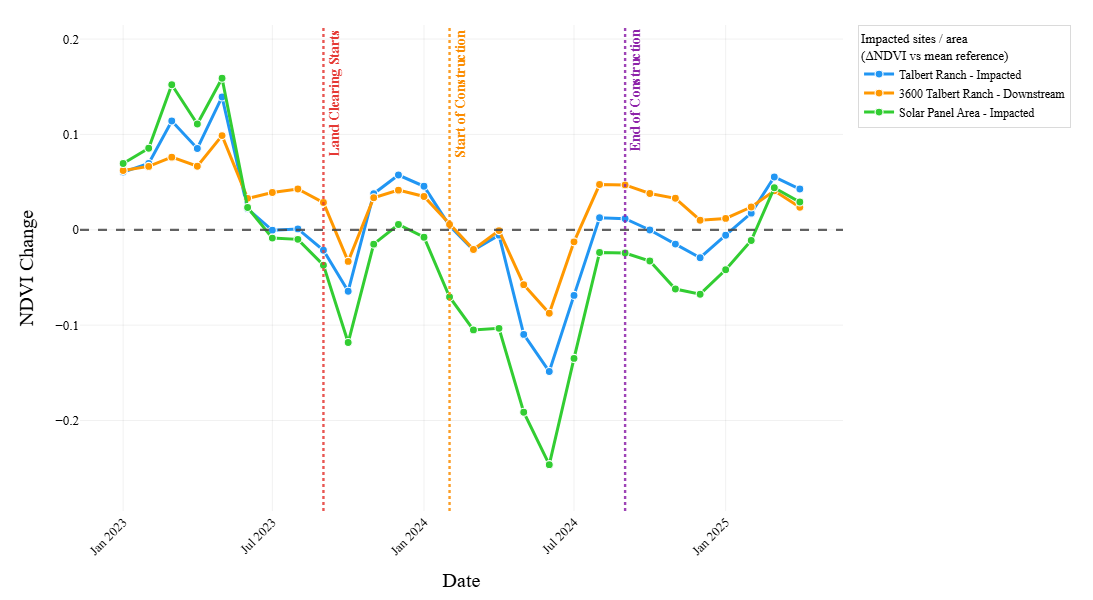

In [20]:
# ============================================================
# Install once in Jupyter if needed:
# %pip install -U kaleido pillow
# ============================================================

import os
import pandas as pd
import plotly.express as px
import plotly.io as pio
from PIL import Image

# Optional: helps Kaleido locate Chrome
try:
    os.environ["BROWSER_PATH"] = str(pio.get_chrome())
except Exception:
    pass


# ============================================================
# USER SETTINGS
# Assumes your dataframe is already loaded as: new_df
# ============================================================

date_col = "month_year"

delta_cols = ["Talbert", "Talbert3600", "SolarFarm"]

legend_label_map = {
    "Talbert": "Talbert Ranch - Impacted",
    "Talbert3600": "3600 Talbert Ranch - Downstream",
    "SolarFarm": "Solar Panel Area - Impacted",
}

# ============================================================
# BRIGHTER VERSION OF YOUR SAME BLUE / ORANGE / GREEN COLORS
# ============================================================

color_discrete_map = {
    "Talbert": "#2196F3",       # brighter blue
    "Talbert3600": "#FF9800",   # brighter orange
    "SolarFarm": "#32CD32",     # brighter green
}

ANNOTATIONS = [
    ("Land Clearing Starts", "2023-09-01", "#E53935"),   # brighter red
    ("Start of Construction", "2024-02-01", "#FB8C00"),  # brighter orange
    ("End of Construction", "2024-09-01", "#8E24AA"),    # brighter purple
]

# Shift annotation text slightly to the right of each vertical line
EVENT_LABEL_XSHIFT = 1

# Output folder and files
OUT_DIR = r"lulc_analysis_report/veg_report/talbert_veg_report/markum/ndvi_plot_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG_600   = os.path.join(OUT_DIR, "markum_monthly_ndvi_delta_600dpi.png")
OUT_PNG_1000  = os.path.join(OUT_DIR, "markum_monthly_ndvi_delta_1000dpi.png")
OUT_PDF       = os.path.join(OUT_DIR, "markum_monthly_ndvi_delta.pdf")
OUT_TIFF_1000 = os.path.join(OUT_DIR, "markum_monthly_ndvi_delta_1000dpi.tif")

# Display size that looks good in Jupyter / Plotly viewer
DISPLAY_WIDTH_PX = 1000
DISPLAY_HEIGHT_PX = 600

# Publication figure width
FIG_WIDTH_IN = 8.3

# Export resolutions
PNG_DPI = 600
TIFF_DPI = 1000

# Darker text and cleaner grid
FONT_COLOR = "black"
AXIS_LABEL_COLOR = "black"
TICK_LABEL_COLOR = "black"
GRID_COLOR = "rgba(0,0,0,0.06)"
ZERO_LINE_COLOR = "rgba(70,70,70,0.85)"
LEGEND_BG = "rgba(255,255,255,0.97)"


# ============================================================
# HELPER FUNCTION FOR GOOD-QUALITY EXPORT
# ============================================================

def export_scaled_png(fig, out_path, dpi, display_width_px, display_height_px, fig_width_in):
    """
    Export Plotly figure so the saved raster keeps the same proportions
    as the good-looking Plotly/Jupyter display version.
    """

    target_width_px = int(fig_width_in * dpi)
    scale_factor = target_width_px / display_width_px

    fig.write_image(
        out_path,
        format="png",
        width=display_width_px,
        height=display_height_px,
        scale=scale_factor
    )

    # Add DPI metadata
    with Image.open(out_path) as img:
        img.save(out_path, dpi=(dpi, dpi))

    print(f"Saved {dpi} dpi PNG: {out_path}")
    print(
        f"Pixel size: "
        f"{int(display_width_px * scale_factor)} x "
        f"{int(display_height_px * scale_factor)}"
    )


# ============================================================
# PREP DATA
# ============================================================

df = new_df.copy()

# Convert date column to datetime
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# Drop rows where date could not be read
df = df.dropna(subset=[date_col]).copy()

# IMPORTANT FIX:
# Convert pandas Timestamp values to plain Python datetime objects.
# This prevents Kaleido/Plotly export errors:
# "Type is not JSON serializable: Timestamp"
df[date_col] = df[date_col].apply(lambda x: x.to_pydatetime())

df_long = df.melt(
    id_vars=[date_col],
    value_vars=delta_cols,
    var_name="Series",
    value_name="NDVI Change"
)

df_long["NDVI Change"] = pd.to_numeric(
    df_long["NDVI Change"],
    errors="coerce"
)

df_long = df_long.dropna(subset=["NDVI Change"]).copy()

# Replace series names with publication-friendly labels
df_long["Series"] = df_long["Series"].map(
    lambda x: legend_label_map.get(x, x)
)

# Plotly color map must use the final displayed legend labels
color_map_for_plot = {
    legend_label_map.get(k, k): v
    for k, v in color_discrete_map.items()
}

# Compute y range with padding
if df_long["NDVI Change"].notna().any():
    y_min = float(df_long["NDVI Change"].min())
    y_max = float(df_long["NDVI Change"].max())
    y_pad = max(0.03, float((y_max - y_min) * 0.12))
else:
    y_min, y_max, y_pad = -0.1, 0.1, 0.03

y_range = [
    float(y_min - y_pad),
    float(y_max + y_pad * 1.15)
]


# ============================================================
# BUILD FIGURE
# ============================================================

fig = px.line(
    df_long,
    x=date_col,
    y="NDVI Change",
    color="Series",
    markers=True,
    color_discrete_map=color_map_for_plot
)

# Brighter, clearer lines and markers
fig.update_traces(
    line=dict(width=3.0),
    marker=dict(
        size=8,
        line=dict(width=1.1, color="white")
    ),
    hovertemplate=(
        "Date: %{x|%b %Y}<br>"
        "%{fullData.name}: %{y:.3f}"
        "<extra></extra>"
    )
)

# Reference line at zero
fig.add_hline(
    y=0,
    line_dash="dash",
    line_color=ZERO_LINE_COLOR,
    line_width=2.2
)

# Vertical event lines + shifted annotations
for txt, d, c in ANNOTATIONS:

    # Use plain Python datetime, not pandas Timestamp
    x = pd.to_datetime(d).to_pydatetime()

    # Keep the vertical stage-period line at the correct date
    fig.add_vline(
        x=x,
        line_dash="dot",
        line_color=c,
        line_width=2.4,
        opacity=0.85
    )

    # Move only the annotation text slightly to the right
    fig.add_annotation(
        x=x,
        y=0.995,
        xref="x",
        yref="paper",
        text=f"<b>{txt}</b>",
        showarrow=False,
        textangle=-90,
        xanchor="left",
        yanchor="top",
        xshift=EVENT_LABEL_XSHIFT,
        font=dict(
            color=c,
            size=14,
            family="Times New Roman, Times, serif"
        )
    )


# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(
    template="plotly_white",
    width=DISPLAY_WIDTH_PX,
    height=DISPLAY_HEIGHT_PX,

    # Remove internal title entirely
    title=None,

    font=dict(
        family="Times New Roman, Times, serif",
        size=14,
        color=FONT_COLOR
    ),

    legend=dict(
        title=dict(
            text="Impacted sites / area<br>(ΔNDVI vs mean reference)",
            font=dict(
                family="Times New Roman, Times, serif",
                size=13,
                color="black"
            )
        ),
        x=1.02,
        y=1.0,
        xanchor="left",
        yanchor="top",
        bgcolor=LEGEND_BG,
        bordercolor="rgba(0,0,0,0.18)",
        borderwidth=0.8,
        font=dict(
            family="Times New Roman, Times, serif",
            size=12,
            color="black"
        )
    ),

    margin=dict(l=80, r=250, t=25, b=75),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_xaxes(
    title_text="Date",
    tickformat="%b %Y",
    dtick="M6",
    tickangle=-45,
    showgrid=True,
    gridcolor=GRID_COLOR,
    gridwidth=1,
    showline=False,
    zeroline=False,
    tickfont=dict(
        family="Times New Roman, Times, serif",
        size=13,
        color=TICK_LABEL_COLOR
    ),
    title_font=dict(
        family="Times New Roman, Times, serif",
        size=20,   # increased x-axis label size
        color=AXIS_LABEL_COLOR
    )
)

fig.update_yaxes(
    title_text="NDVI Change",
    range=y_range,
    showgrid=True,
    gridcolor=GRID_COLOR,
    gridwidth=1,
    zeroline=False,
    showline=False,
    tickfont=dict(
        family="Times New Roman, Times, serif",
        size=13,
        color=TICK_LABEL_COLOR
    ),
    title_font=dict(
        family="Times New Roman, Times, serif",
        size=20,   # increased y-axis label size
        color=AXIS_LABEL_COLOR
    )
)


# ============================================================
# EXPORT
# ============================================================

print("\nExporting NDVI figure...")

# 600 dpi PNG
try:
    export_scaled_png(
        fig,
        OUT_PNG_600,
        dpi=PNG_DPI,
        display_width_px=DISPLAY_WIDTH_PX,
        display_height_px=DISPLAY_HEIGHT_PX,
        fig_width_in=FIG_WIDTH_IN
    )
except Exception as e:
    print(f"600 dpi PNG export failed: {e}")

# 1000 dpi PNG
try:
    export_scaled_png(
        fig,
        OUT_PNG_1000,
        dpi=TIFF_DPI,
        display_width_px=DISPLAY_WIDTH_PX,
        display_height_px=DISPLAY_HEIGHT_PX,
        fig_width_in=FIG_WIDTH_IN
    )
except Exception as e:
    print(f"1000 dpi PNG export failed: {e}")

# PDF export
# PDF is vector-based, so export at display size.
try:
    fig.write_image(
        OUT_PDF,
        format="pdf",
        width=DISPLAY_WIDTH_PX,
        height=DISPLAY_HEIGHT_PX,
        scale=1
    )
    print(f"Saved PDF: {OUT_PDF}")
except Exception as e:
    print(f"PDF export failed: {e}")

# TIFF export from 1000 dpi PNG
try:
    if os.path.exists(OUT_PNG_1000):
        with Image.open(OUT_PNG_1000) as img:
            img.save(
                OUT_TIFF_1000,
                dpi=(TIFF_DPI, TIFF_DPI),
                compression="tiff_lzw"
            )
        print(f"Saved 1000 dpi TIFF: {OUT_TIFF_1000}")
    else:
        print("TIFF export skipped because the 1000 dpi PNG was not created.")
except Exception as e:
    print(f"TIFF export failed: {e}")


# ============================================================
# SHOW FIGURE
# ============================================================

fig.show()